In [24]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from tqdm import tqdm

# 1. Статистический анализ результатов прямого численного моделирования

(а) Определим процедуру `step_stochastic`, задающую шаг стохастической системы, и запишем стохастические системы FHN и SN.

In [25]:
def step_stochastic(
    model_func: callable,
    params: dict,
    state: np.ndarray,
    dt: float,
    epsilon: float,
    noise_mask: np.ndarray = np.array([1, 1]),
    rng: np.random.Generator = np.random.default_rng(),
):
    """
    Euler-Maruyama step for stochastic system given by `model_func` with `params`.

    Args:
        dt: integration step
        epsilon: noise intensity (when set to 0, the system is considered deterministic)
        noise_mask: denotes the equations to which noise should be added (noise vector is multiplied by the noise mask element-wise)
    
    Returns:
        system state after the randomized step
    """
    drift = model_func(0, state, **params)
    
    dW1 = rng.normal(0., 1.) * np.sqrt(dt)
    dW2 = rng.normal(0., 1.) * np.sqrt(dt)
    noise = np.array([epsilon * dW1, epsilon * dW2]) * noise_mask
    
    return state + drift * dt + noise

FHN с аддитивным шумом в 1-м уравнении:  
$$
\begin{cases}
    \dot{x} = \frac{1}{\delta} (x - \frac{x^3}{3} - y) + \varepsilon \cdot \xi_1 \\
    \dot{y} = x + a
\end{cases}
$$

In [26]:
def model_FHN(
    time: float,
    state: np.ndarray,
    delta: float = 0.1,
    a: float = 1,
):
    """
    FitzHugh-Nagumo neural model.
    Accepts `time` argument for interface consistency, but does not use it.
    
    Parameter restrictions:
    - delta << 1 (delta = 0.1)
    - a > 0
    """
    x, y = state
    return np.array([
        (x - (x ** 3) / 3 - y) / delta,
        x + a
    ])

SN с аддитивным шумом в обоих уравнениях:  
$$
\begin{cases}
    \dot{x} = y - x + \varepsilon \cdot \xi_1 \\
    \dot{y} = -a x + b y - x^2 y + \varepsilon \cdot \xi_2
\end{cases}
$$

In [27]:
def model_SN(
    time: float,
    state: np.ndarray,
    a: float = 1,
    b: float = 2,
):
    """
    Saltzman-Nicolis climate model.
    Accepts `time` argument for interface consistency, but does not use it.
    
    Parameter restrictions:
    - a > 0
    - b = 2
    """
    x, y = state
    return np.array([
        y - x,
        -a * x + b * y - (x ** 2) * y
    ])

(б) Для устойчивых равновесий построим облака случайных траекторий для разных значений интенсивности шума $\varepsilon$.

In [36]:
def simulate_trajectory(
    model_func: callable,
    params: dict,
    state_init: np.ndarray,
    time_span: np.ndarray,
    epsilon: float,
    noise_mask: np.ndarray,
    rng: np.random.Generator,
):
    n = len(time_span)
    dt = time_span[1] - time_span[0]
    
    trajectory = np.zeros((n, 2))
    trajectory[0] = state_init
    
    for i in range(n - 1):
        trajectory[i + 1] = step_stochastic(
            model_func=model_func,
            params=params,
            state=trajectory[i],
            dt=dt,
            epsilon=epsilon,
            noise_mask=noise_mask,
            rng=rng,
        )
    
    return trajectory

def plot_stochastic_cloud(
    ax: plt.Axes,
    model_func: callable,
    params: dict,
    equilibrium: np.ndarray,
    time_span: np.ndarray,
    epsilon: float,
    noise_mask: np.ndarray,
    n_trajectories: int = 50,
    spread_init: float = 0.05,
    seed: int = 42,
):
    rng = np.random.default_rng(seed)
    trajectories = []
    
    for _ in range(n_trajectories):
        # start near the equilirium
        state_init = equilibrium + rng.normal(0, spread_init, size=2)
        
        trajectory = simulate_trajectory(
            model_func=model_func,
            params=params,
            state_init=state_init,
            time_span=time_span,
            epsilon=epsilon,
            noise_mask=noise_mask,
            rng=rng,
        )
        
        ax.plot(trajectory[:, 0], trajectory[:, 1], alpha=0.3)
        trajectories.append(trajectory)
    
    ax.scatter(*equilibrium, color='red', s=50, zorder=100, label='equilibrium')
    ax.set_title(f"Noise cloud ({epsilon=})")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(loc="upper right")
    ax.grid(True)

    return trajectories

Облака траекторий системы FHN вблизи устойчивого равновесия $(\overline{x}, \overline{y}) = (-a, \frac{a^3}{3} - a)$ при $a > 1$:

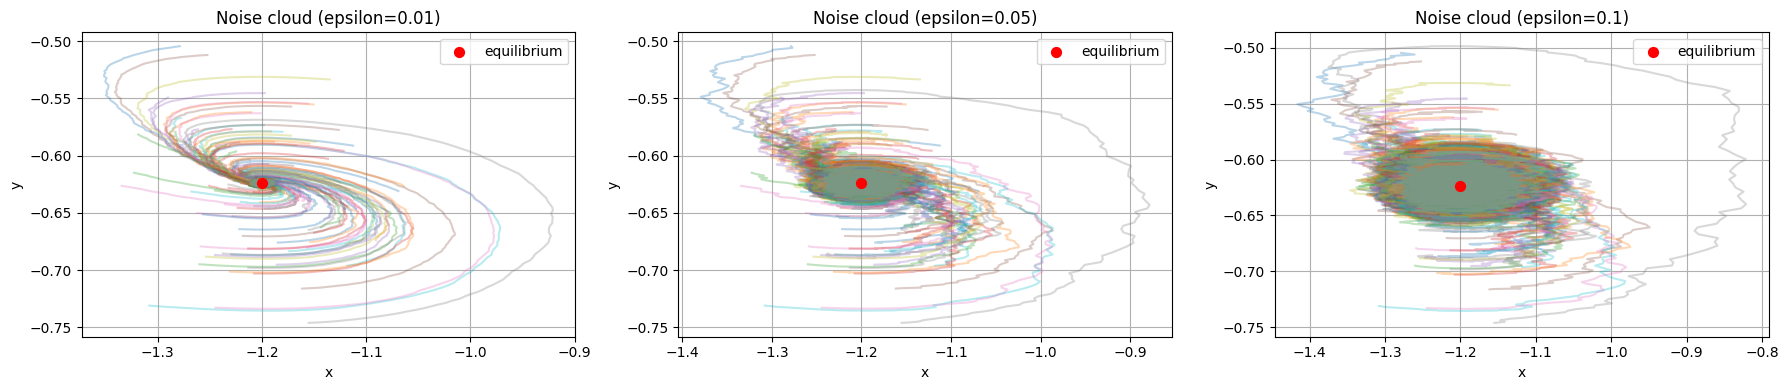

In [29]:
delta, a = 0.1, 1.2

equilibrium = np.array([-a, a**3 / 3 - a])

noise_mask = np.array([1, 0])   # add noise to 1st equation only
epsilon_values = [0.01, 0.05, 0.1]
time_span = np.linspace(0, 50, 5000)

fig, axes = plt.subplots(1, len(epsilon_values), figsize=(18, 4))

for ax, epsilon in zip(axes, epsilon_values):
    plot_stochastic_cloud(
        ax=ax,
        model_func=model_FHN,
        params=dict(delta=delta, a=a),
        equilibrium=equilibrium,
        time_span=time_span,
        epsilon=epsilon,
        noise_mask=noise_mask,
        n_trajectories=100
    )

plt.tight_layout()
plt.show()

Облака траекторий системы SN вблизи устойчивого равновесия $(\overline{x}, \overline{y}) = (0, 0)$:

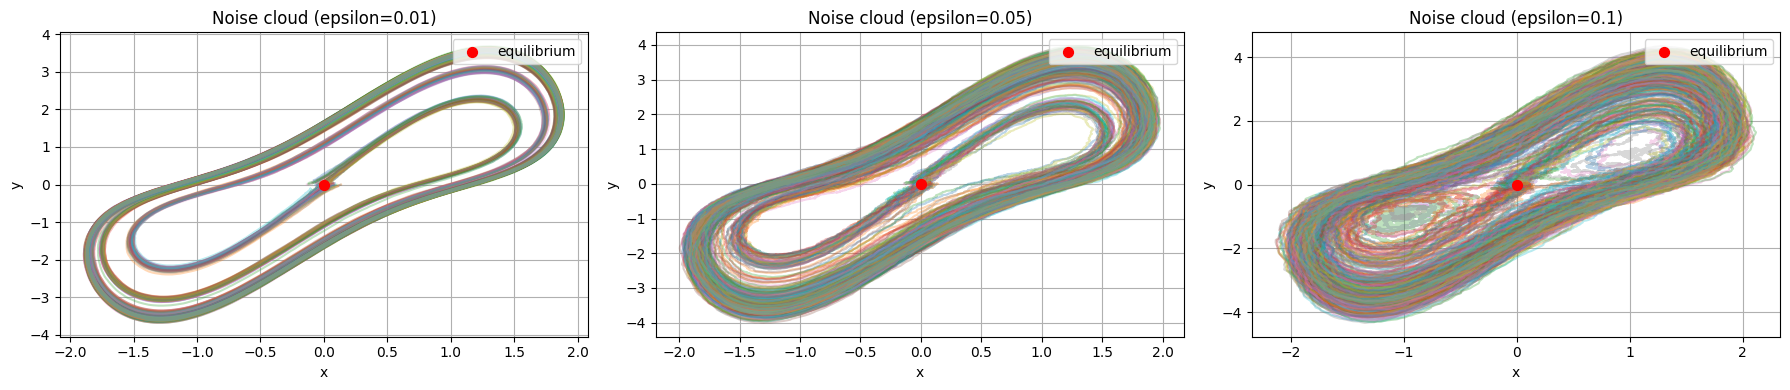

In [30]:
a, b = 1, 2

equilibrium = np.array([0, 0])

noise_mask = np.array([1, 1])   # add noise to both equations
epsilon_values = [0.01, 0.05, 0.1]
time_span = np.linspace(0, 50, 5000)

fig, axes = plt.subplots(1, len(epsilon_values), figsize=(18, 4))

for ax, epsilon in zip(axes, epsilon_values):
    plot_stochastic_cloud(
        ax=ax,
        model_func=model_SN,
        params=dict(a=a, b=b),
        equilibrium=equilibrium,
        time_span=time_span,
        epsilon=epsilon,
        noise_mask=noise_mask,
        n_trajectories=100
    )

plt.tight_layout()
plt.show()

(в) Запишем матрицу ковариации, найдем ее собственные числа $\overline{\lambda_1}(a), \overline{\lambda_2}(a)$.

$$
\operatorname{cov}(x, y) =
\begin{pmatrix}
    \frac{1}{n} \sum_{i=1}^n (x_i - \bar{x})^2 & \frac{1}{n} \sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y}) \\
    \frac{1}{n} \sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y}) & \frac{1}{n} \sum_{i=1}^n (y_i - \bar{y})^2
\end{pmatrix}
$$

In [38]:
def compute_covariance_matrix(
    trajectories: list[np.ndarray],
    clip_ratio: float = 0.5,
) -> np.ndarray:
    """
    Compute 2x2 covariance matrix for a stochastic cloud.

    Args:
        trajectories: list of trajectories of shape `(n_steps, 2)`
    
    Returns:
        cov_matrix: covariance matrix
        points_concat: stochastic cloud after clipping the transient
    """
    points = []
    
    for trajectory in trajectories:
        # clip transient (consider only the asymptotic behavior of the system)
        clip = int(len(trajectory) * clip_ratio)
        traj_stationary = trajectory[clip:]
        points.append(traj_stationary)
    
    points_concat = np.vstack(points)  # shape (N_total, 2)
    cov_matrix = np.cov(points_concat.T)
    
    return cov_matrix, points_concat

def compute_eigenvalues(matrix: np.ndarray) -> tuple:
    """
    Compute eigenvalues and eigenvectors of the matrix and return them in descending order.
    """
    eigvals, eigvecs = np.linalg.eigh(matrix)
    return eigvals[::-1], eigvecs[:, ::-1]

In [39]:
trajectories = plot_stochastic_cloud(
    ax=ax,
    model_func=model_FHN,
    params=dict(delta=delta, a=a),
    equilibrium=equilibrium,
    time_span=time_span,
    epsilon=epsilon,
    noise_mask=noise_mask,
    n_trajectories=100
)

cov, pts = compute_covariance_matrix(
    trajectories=trajectories
)

eigvals, eigvecs = compute_eigenvalues(cov)

In [40]:
cov

array([[ 1.0814528 , -0.00970013],
       [-0.00970013,  0.41967625]])

In [41]:
eigvals

array([1.08159495, 0.4195341 ])

In [42]:
eigvecs

array([[-0.99989264, -0.01465299],
       [ 0.01465299, -0.99989264]])

Построим графики зависимостей $\overline{\lambda_1}(a), \overline{\lambda_2}(a)$ в зоне устойчивых равновесий $(a_1, a_2)$ (зависимость от чего, от $\varepsilon$? уточнить в лекциях!). Сравним графики для выборок размеров $N = 10^3$ и $N = 10^6$.

In [32]:
pass

# 2. Анализ с помощью метода стохастической чувствительности
(а) Решить уравнение (3) в общем виде.

Записать матрицу стохастической чувствительности $W$ для FHN и SN.

In [33]:
pass

(б) Найти собственные числа $\lambda_1, \lambda_2$ матрицы $W$.

Построить зависимости $\varepsilon \cdot \lambda_1(a), \varepsilon \cdot \lambda_2(a)$ для $\varepsilon$ из пункта 1 (б).

Сравнить с графиками из пункта 1 (в).

In [34]:
pass

(в) Для выбранных нескольких значений параметра $a$ построить доверительные эллипсы (можно взять облако из пункта 1 (б) и построить для этих же данных доверительные эллипсы).

In [35]:
pass